In [1]:
import numpy as np
import sys
import os
from IPython.display import HTML

from ipynb.fs.full.vis import visualize_trajectories, plot_static_trajectories
from ipynb.fs.full.analysis import numerical_analysis

sys.path.append(os.path.abspath("../py"))
from forcemodel import IForceModel, GravityForce
from integrator import IIntegrator, SymplecticEuler, VelocityVerlet
from env import SolarSystemEnv, run_simulation, run_script_simulation, adjust_barycentric
from helpers import save_states, load_states

In [2]:
%load_ext autoreload
%autoreload 2

# ***THIS NOTEBOOK IS PURELY FOR PHYSICS SIMULATION STABILITY ANALYSIS*** #

In [4]:
bodies = [
    # Masses (kg)
    np.array([
        1.5e10,
        1.5e10,
        1.5e10,
    ]),
    # Positions (x, y) in meters (approx semi-major axes on x-axis)
    np.array([
        [0.97, -0.243],
        [-0.97, 0.4], #[-0.97, 0.243],
        [0.0, 0.0], 
    ]),
    # Velocities (vx, vy) in m/s (circular orbit approximation)
    np.array([
        [0.466, 0.432],
        [0.466, 0.432],
        [-0.932, -0.864], 
    ]),
    # Names
    np.array([
        "One",
        "Two",
        "Three",
    ]),
    # Colors (reasonable defaults for visualization)
    np.array([
        "red",
        "blue",
        "green",
    ]),
]

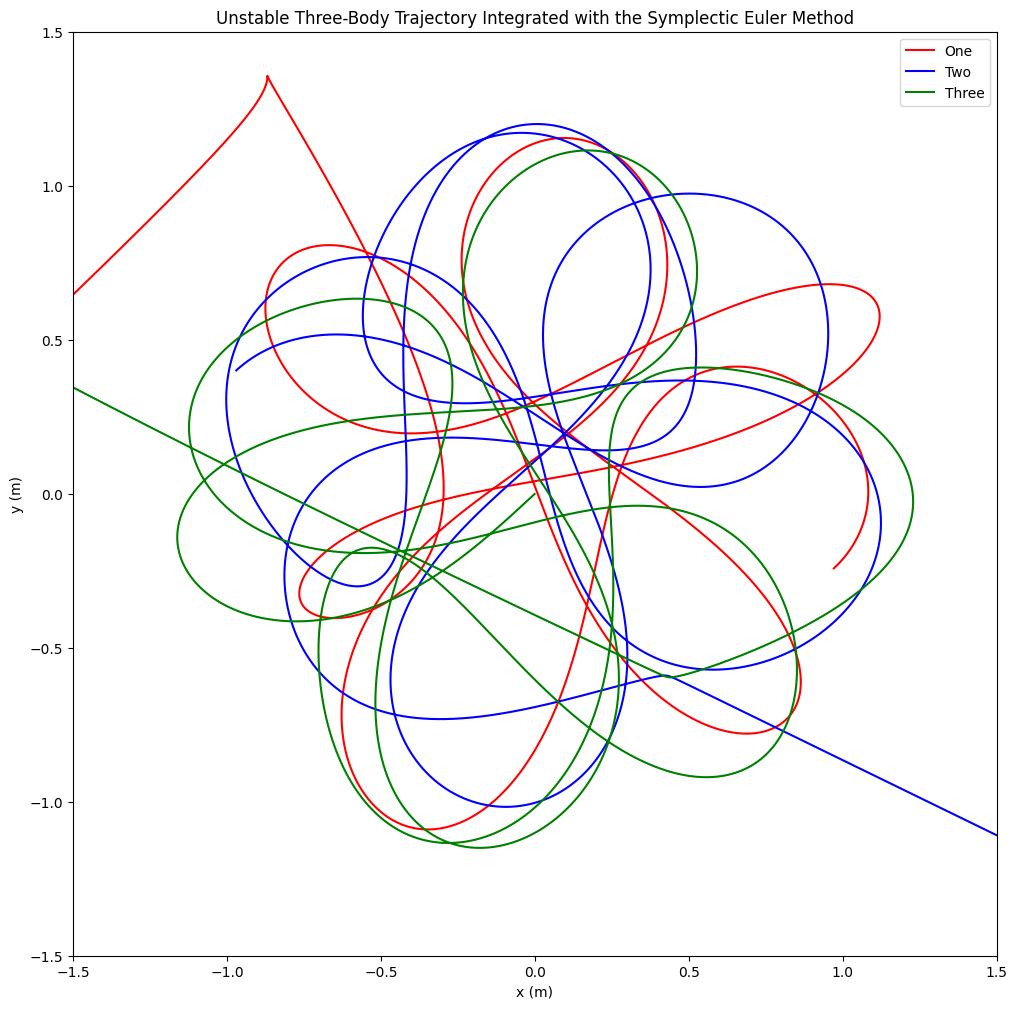

In [5]:
dt=0.001
n_steps=100000
states = run_simulation(GravityForce, SymplecticEuler, bodies, dt=dt, n_steps=n_steps, records_len=100000)
plot_static_trajectories(states=states, body_names=bodies[3], colors=bodies[4], scale=1.0, xlim=(-1.5, 1.5), ylim=(-1.5, 1.5), xlabel="x (m)", ylabel="y (m)", title="Unstable Three-Body Trajectory Integrated with the Symplectic Euler Method",save_path=None)#, save_path="threebodyunstableeulervis.pdf")

In [6]:
bodies = [
    # Masses (kg)
    np.array([
        1.5e10,
        1.5e10,
        1.5e10,
    ]),
    # Positions (x, y) in meters (approx semi-major axes on x-axis)
    np.array([
        [0.97, -0.243],
        [-0.97, 0.243],
        [0.0, 0.0], 
    ]),
    # Velocities (vx, vy) in m/s (circular orbit approximation)
    np.array([
        [0.466, 0.432],
        [0.466, 0.432],
        [-0.932, -0.864], 
    ]),
    # Names
    np.array([
        "One",
        "Two",
        "Three",
    ]),
    # Colors (reasonable defaults for visualization)
    np.array([
        "red",
        "blue",
        "green",
    ]),
]
dt=0.001
n_steps=10000000

In [7]:
states = run_simulation(GravityForce, SymplecticEuler, bodies, dt=dt, n_steps=n_steps, records_len=100000)
#save_states(f"states_3body_(dt{dt}st{int(n_steps/1000)}k_euler.json", states)

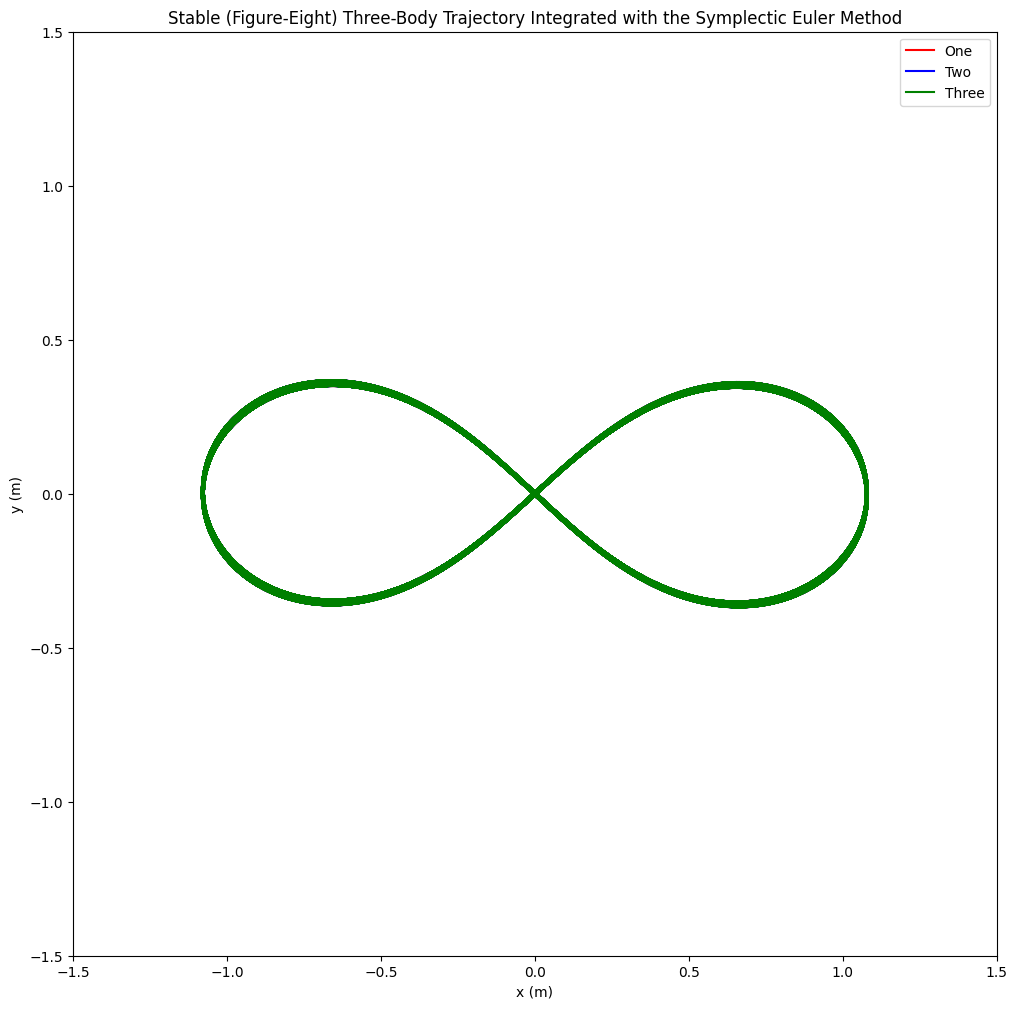

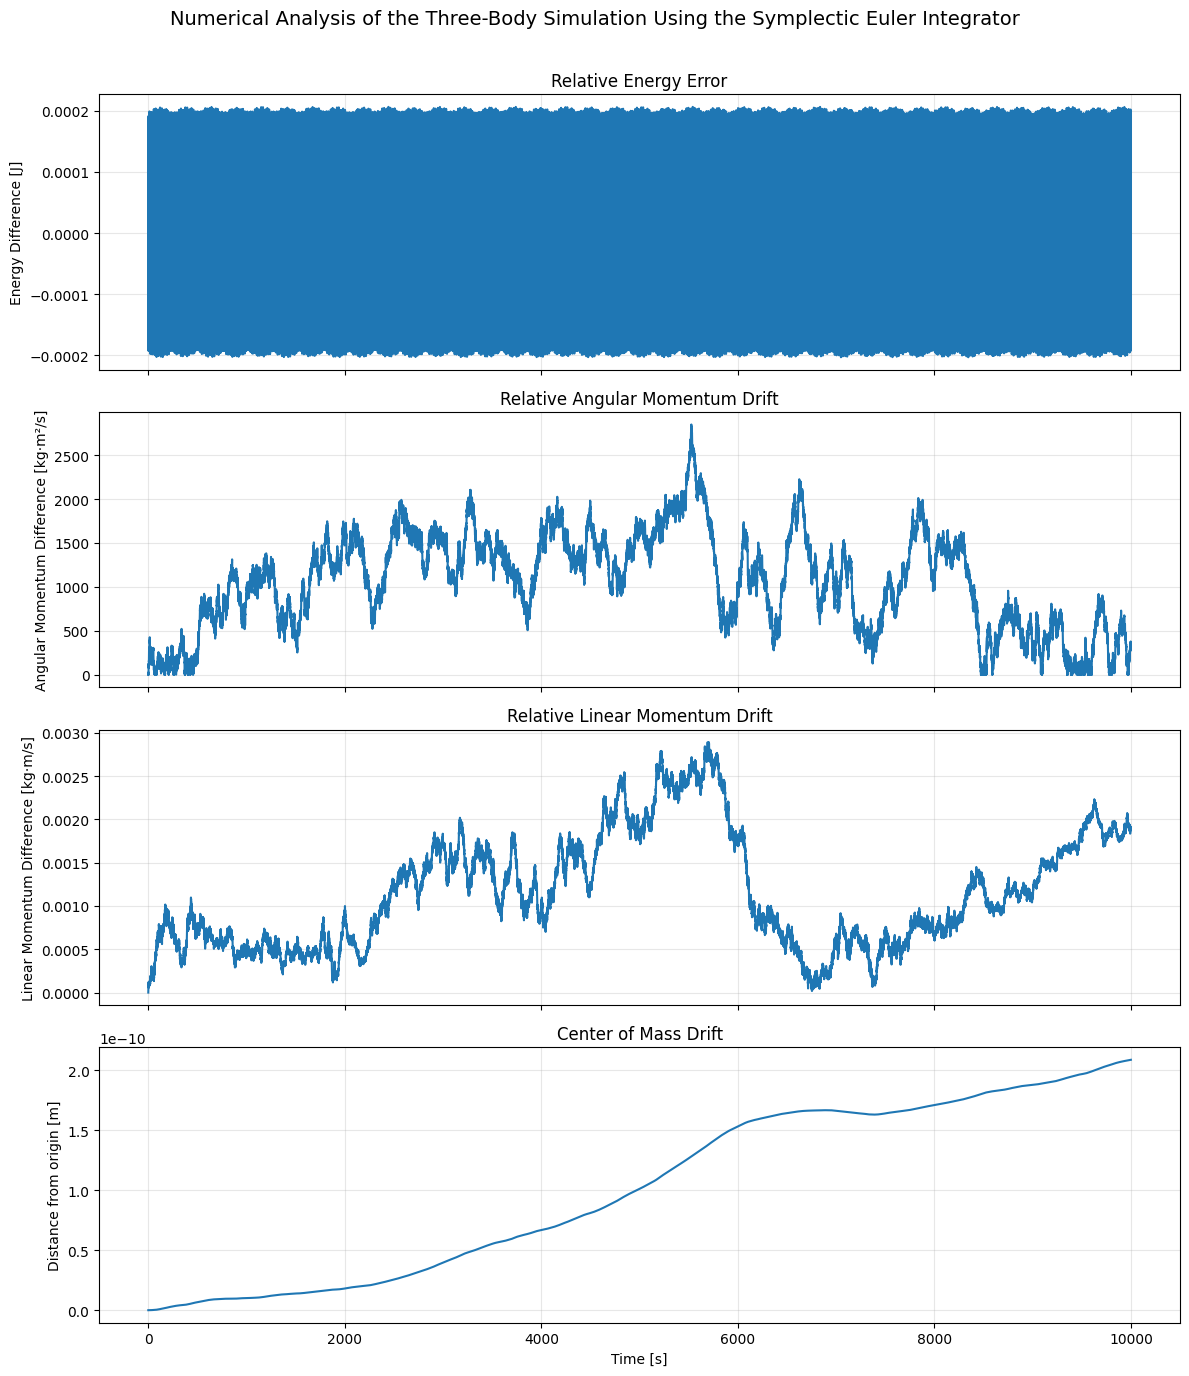

In [8]:
#states = load_states("states_3body_(dt0.001st10000k_euler.json")
plot_static_trajectories(states=states, body_names=bodies[3], colors=bodies[4], scale=1.0, xlim=(-1.5, 1.5), ylim=(-1.5, 1.5), xlabel="x (m)", ylabel="y (m)", title="Stable (Figure-Eight) Three-Body Trajectory Integrated with the Symplectic Euler Method",save_path=None)#, save_path="threebodyeulervis.pdf") #, save_path="threebodyeulervis.pdf")
numerical_analysis(states, title="Numerical Analysis of the Three-Body Simulation Using the Symplectic Euler Integrator",save_path=None)#, save_path="numerical_analysis_3b_euler.pdf") #save_path="numerical_analysis_1.pdf"

In [9]:
states = run_simulation(GravityForce, VelocityVerlet, bodies, dt=dt, n_steps=n_steps, records_len=100000)
#save_states(f"states_3body_(dt{dt}st{int(n_steps/1000)}k_verlet.json", states)

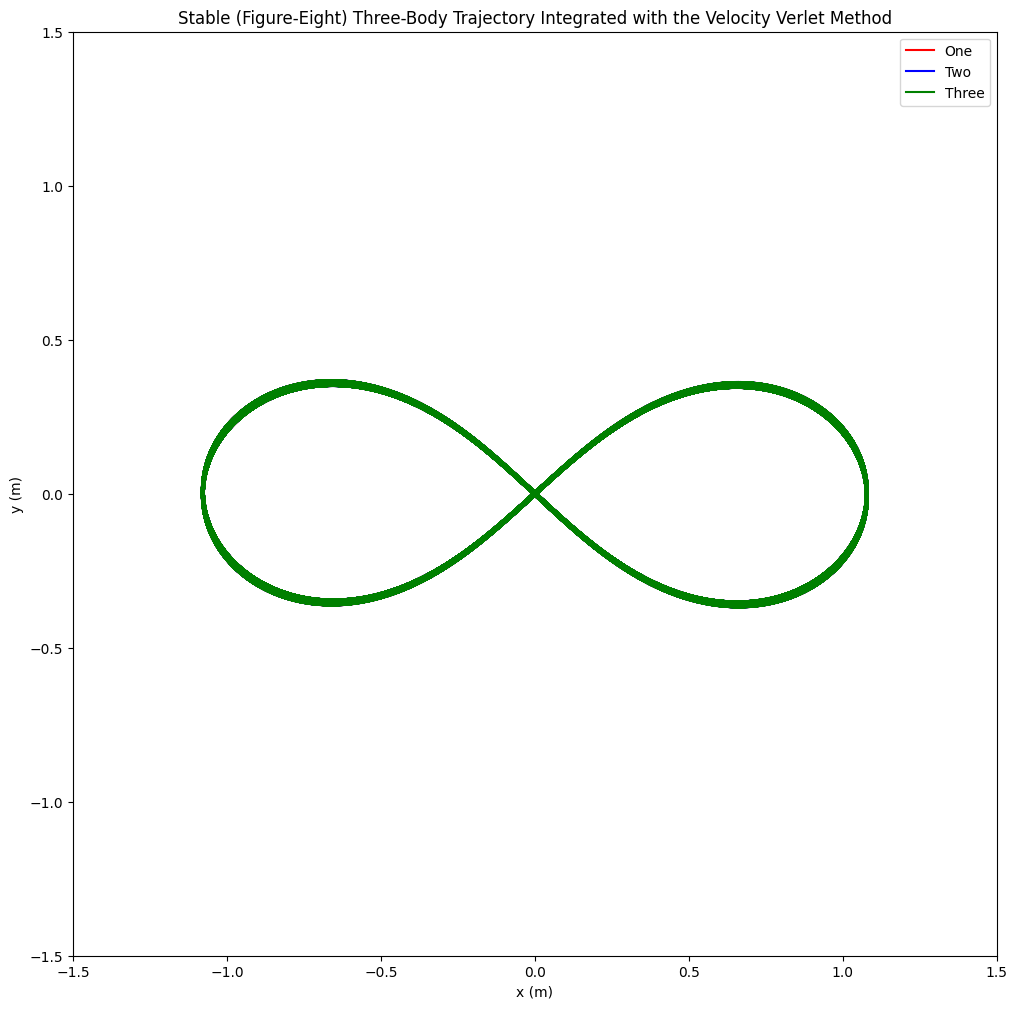

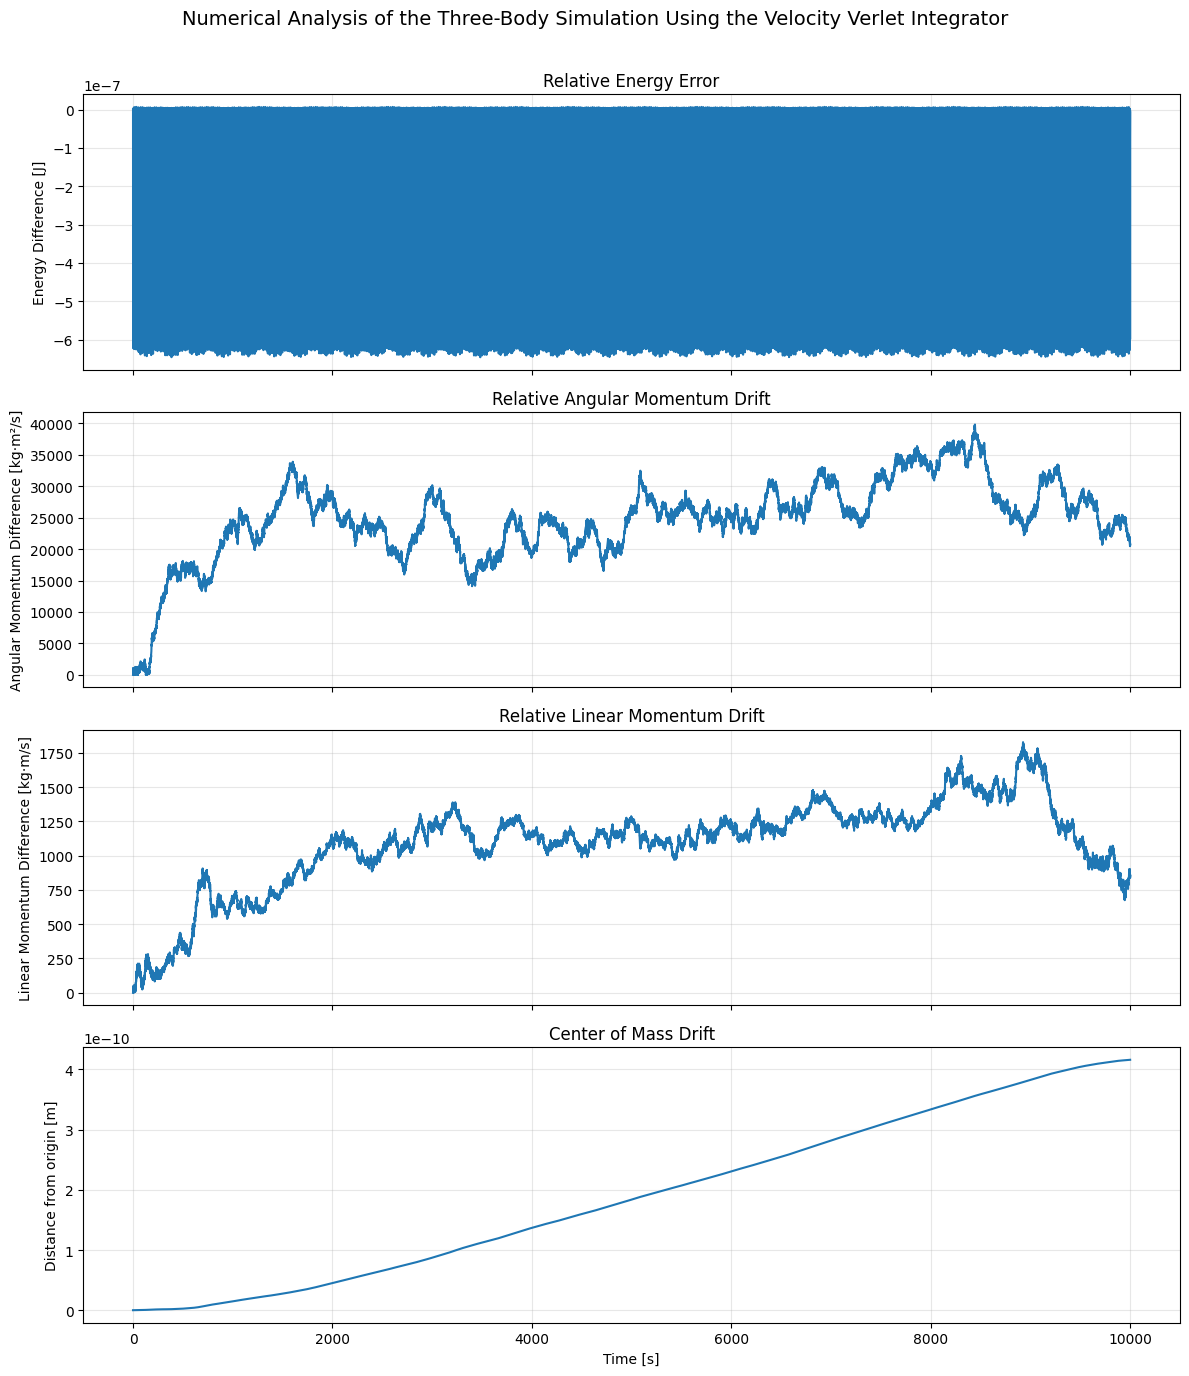

In [10]:
#states = load_states("states_3body_(dt0.001st10000k_verlet.json")
plot_static_trajectories(states=states, body_names=bodies[3], colors=bodies[4], scale=1.0, xlim=(-1.5, 1.5), ylim=(-1.5, 1.5), xlabel="x (m)", ylabel="y (m)", title="Stable (Figure-Eight) Three-Body Trajectory Integrated with the Velocity Verlet Method",save_path=None)#, save_path="threebodyverletvis.pdf")#, save_path="threebodyverletvis.pdf")
numerical_analysis(states, title="Numerical Analysis of the Three-Body Simulation Using the Velocity Verlet Integrator",save_path=None)#, save_path="numerical_analysis_3b_verlet.pdf")  #save_path="numerical_analysis_2.pdf"

In [11]:
#anim = visualize_trajectories(states=states, body_names=bodies[3], colors=bodies[4], interval=40, scale=1.0, xlim=(-2.0, 2.0), ylim=(-2.0, 2.0), save_path=None) #save_path="3bodyproblem.gif")
#HTML(anim.to_jshtml())